# Assignment 1 2AMM10 2025-2026

## Group: no
### Member 1: Alexia Dragomirescu
### Member 2: Ana Sirbu
### Member 3: Carina Ungureanu

In [54]:
%matplotlib inline

In [28]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [29]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

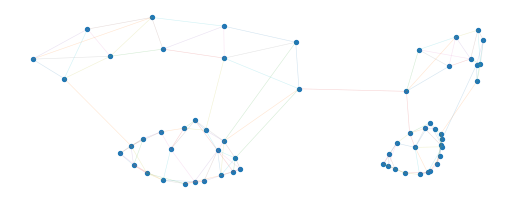

In [30]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [31]:

from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader
import torch.nn.functional as F


class GraphSAGE(nn.Module):
    """
    GraphSAGE model for graph-level binary classification (awake vs drowsy).

    Architecture (Geometric Deep Learning blueprint):
        [SAGEConv → BN → ReLU → Dropout] × num_layers   # equivariant layers
        → global_mean_pool                                # invariant global pooling
        → MLP head (Linear → ReLU → Dropout → Linear)    # binary classifier

    SAGEConv update rule (mean variant):
        x_i^(k) = W1 * x_i^(k-1)  +  (1/|N(i)|) * Σ_{j ∈ N(i)} x_j^(k-1)

    Parameter re-use across all nodes makes the layer permutation-equivariant.
    Mean aggregation over N(i) is permutation-invariant (nodes have no canonical ordering).

    Output: scalar logit per graph (positive = drowsy).
            Use BCEWithLogitsLoss during training; sigmoid ≥ 0.5 at inference.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 64,
        num_layers: int = 3,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer: in_channels → hidden_channels
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Remaining GNN layers: hidden_channels → hidden_channels
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # MLP classification head (maps graph embedding → scalar logit)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),  # scalar output; BCEWithLogitsLoss applies sigmoid
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor):
        # Equivariant message-passing layers
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Invariant global pooling: collapse node embeddings into one graph embedding
        x = global_mean_pool(x, batch)  # [num_graphs, hidden_channels]

        # Binary classification head
        return self.mlp(x).squeeze(-1)  # [num_graphs]  (scalar logit per graph)


In [32]:

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_dataset_graph = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset_graph  = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset_graph, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset_graph,  batch_size=BATCH_SIZE, shuffle=False)

# ── Model, optimiser ─────────────────────────────────────────────────────────
IN_CHANNELS     = train_dataset_graph[0].x.shape[1]  # 3 (x, y, z coordinates)
HIDDEN_CHANNELS = 64    # smaller width reduces overfitting on 400-sample dataset
NUM_LAYERS      = 3
DROPOUT         = 0.3
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
EPOCHS          = 100   # more epochs; cosine LR decays slowly, best checkpoint saved

model     = GraphSAGE(IN_CHANNELS, HIDDEN_CHANNELS, NUM_LAYERS, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters : {total_params:,}")
print(f"Training samples     : {len(train_dataset_graph)}")
print(f"Test samples         : {len(test_dataset_graph)}")
print(f"Node features        : {IN_CHANNELS}")
print(f"Classes              : {train_dataset_graph.id_to_class}")
print(f"Device               : {DEVICE}")


GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(3, 64, aggr=mean)
    (1-2): 2 x SAGEConv(64, 64, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 19,457
Training samples     : 400
Test samples         : 100
Node features        : 3
Classes              : {'0': 'awake', '1': 'drowsy'}
Device               : cuda


In [33]:

# ── Helper functions ─────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, device):
    """One training epoch using BCEWithLogitsLoss (numerically stable binary CE)."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        # Labels must be float for BCEWithLogitsLoss
        loss = F.binary_cross_entropy_with_logits(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    """
    Returns (loss, recall, precision) for the positive class (drowsy=1).

    Recall    = TP / (TP + FN)  — fraction of truly drowsy drivers detected.
                Critical in safety-critical driving: a missed drowsy driver
                (FN) prevents a safety alarm from triggering.
    Precision = TP / (TP + FP)  — fraction of drowsy predictions that are correct.

    Task requirement: both metrics must reach ≥ 0.6 on the test set.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        total_loss += F.binary_cross_entropy_with_logits(logits, batch.y.float()).item() * batch.num_graphs
        preds = (torch.sigmoid(logits) >= 0.5).long()
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    TP = ((all_preds == 1) & (all_labels == 1)).sum().item()
    FP = ((all_preds == 1) & (all_labels == 0)).sum().item()
    FN = ((all_preds == 0) & (all_labels == 1)).sum().item()

    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    avg_loss  = total_loss / len(loader.dataset)

    return avg_loss, recall, precision


# ── Training loop ─────────────────────────────────────────────────────────────
best_recall   = 0.0
train_losses  = []
test_losses   = []
test_recalls  = []
test_precs    = []

for epoch in range(1, EPOCHS + 1):
    train_loss              = train_epoch(model, train_loader, optimizer, DEVICE)
    test_loss, recall, prec = evaluate(model, test_loader, DEVICE)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_recalls.append(recall)
    test_precs.append(prec)

    # Save best checkpoint based on recall (most safety-critical metric)
    if recall > best_recall:
        best_recall = recall
        torch.save(model.state_dict(), "model_task1_sage.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS}  |  "
            f"Train Loss: {train_loss:.4f}  |  "
            f"Test Loss: {test_loss:.4f}  |  "
            f"Recall: {recall:.4f}  |  "
            f"Precision: {prec:.4f}"
        )

print(f"\nBest test recall: {best_recall:.4f}")

# ── Final evaluation with best checkpoint ────────────────────────────────────
model.load_state_dict(torch.load("model_task1_sage.pth", weights_only=True))
_, final_recall, final_prec = evaluate(model, test_loader, DEVICE)

print("\n── Final Test Set Results ───────────────────────────────────")
print(f"  Recall    (TP/(TP+FN)): {final_recall:.4f}  {'✓ >= 0.6' if final_recall >= 0.6 else '✗ < 0.6'}")
print(f"  Precision (TP/(TP+FP)): {final_prec:.4f}  {'✓ >= 0.6' if final_prec >= 0.6 else '✗ < 0.6'}")
print("─────────────────────────────────────────────────────────────")


Epoch   1/100  |  Train Loss: 0.6755  |  Test Loss: 0.6893  |  Recall: 0.1200  |  Precision: 0.3333
Epoch  10/100  |  Train Loss: 0.4595  |  Test Loss: 0.4940  |  Recall: 0.6200  |  Precision: 0.8378
Epoch  20/100  |  Train Loss: 0.4023  |  Test Loss: 0.4241  |  Recall: 0.5800  |  Precision: 0.9062
Epoch  30/100  |  Train Loss: 0.3737  |  Test Loss: 0.4291  |  Recall: 0.6000  |  Precision: 0.9677
Epoch  40/100  |  Train Loss: 0.3392  |  Test Loss: 0.3959  |  Recall: 0.6800  |  Precision: 0.9444
Epoch  50/100  |  Train Loss: 0.3415  |  Test Loss: 0.3681  |  Recall: 0.7000  |  Precision: 0.9459
Epoch  60/100  |  Train Loss: 0.3312  |  Test Loss: 0.3494  |  Recall: 0.8200  |  Precision: 0.9535
Epoch  70/100  |  Train Loss: 0.3133  |  Test Loss: 0.3285  |  Recall: 0.8400  |  Precision: 0.9333
Epoch  80/100  |  Train Loss: 0.3103  |  Test Loss: 0.3412  |  Recall: 0.8200  |  Precision: 0.9111
Epoch  90/100  |  Train Loss: 0.2955  |  Test Loss: 0.3373  |  Recall: 0.8200  |  Precision: 0.9318


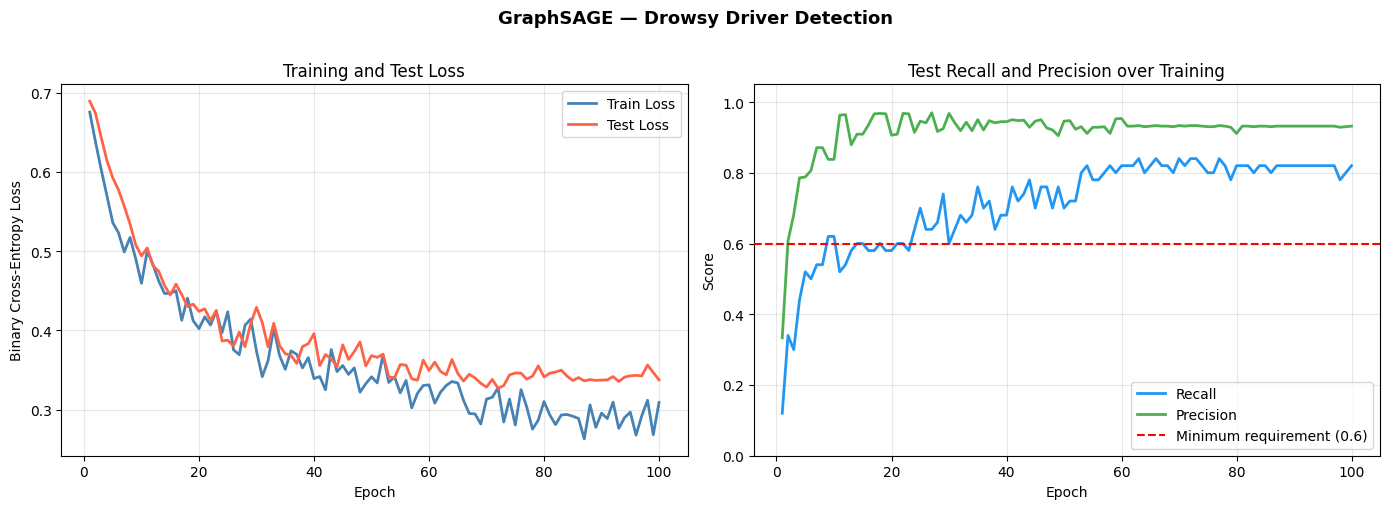

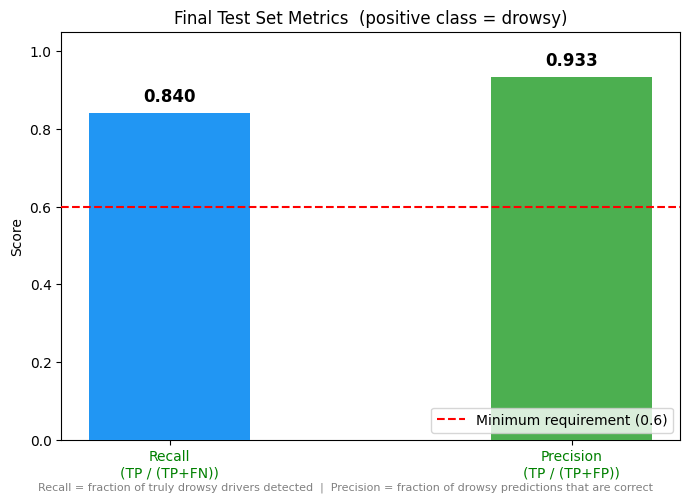

In [34]:

# ── Training curves ────────────────────────────────────────────────────────────
# Run this cell independently to regenerate plots without retraining.

ep = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Loss curves ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ep, train_losses, label="Train Loss", color="steelblue", linewidth=2)
ax.plot(ep, test_losses,  label="Test Loss",  color="tomato",    linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Training and Test Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: Recall and Precision over epochs ────────────────────────────────────
ax = axes[1]
ax.plot(ep, test_recalls, label="Recall",    color="#2196F3", linewidth=2)
ax.plot(ep, test_precs,   label="Precision", color="#4CAF50", linewidth=2)
ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Test Recall and Precision over Training")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("GraphSAGE — Drowsy Driver Detection", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar chart: final Recall vs Precision ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
names  = ["Recall\n(TP / (TP+FN))", "Precision\n(TP / (TP+FP))"]
values = [final_recall, final_prec]
colors = ["#2196F3", "#4CAF50"]

bars = ax.bar(names, values, color=colors, width=0.4, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Final Test Set Metrics  (positive class = drowsy)")
ax.legend(loc="lower right")

for tick, val in zip(ax.get_xticklabels(), values):
    tick.set_color("green" if val >= 0.6 else "red")

fig.text(0.5, 0.01,
         "Recall = fraction of truly drowsy drivers detected  |  "
         "Precision = fraction of drowsy predictions that are correct",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("test_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


# Task 2

In [35]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

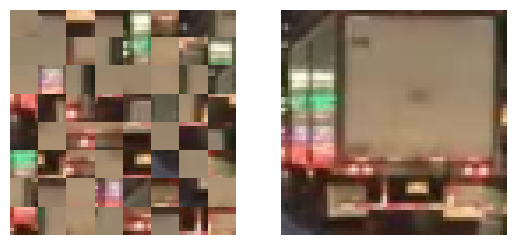

In [36]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [37]:
class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, patch_size=8):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class PatchShuffleInvariantTransformer(nn.Module):
    def __init__(
        self,
        num_classes,
        img_size=64,
        patch_size=8,
        embed_dim=128,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.patch_embed = PatchEmbed(3, embed_dim, patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        patches = self.patch_embed(x)  # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)  # [B, 1, D]
        tokens = torch.cat([cls, patches], dim=1)  # [B, 1+N, D]

        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)

        cls_out = tokens[:, 0]
        logits = self.head(cls_out)
        return logits


In [38]:
from sklearn.metrics import precision_score, recall_score


def train_model(model, train_loader, device, epochs=15, lr=3e-4, weight_decay=1e-4):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}/{epochs} | loss: {running_loss / total:.4f} "
            f"| train acc: {correct / total:.4f}"
        )
    return model


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def compute_metrics(preds, labels, num_classes):
    class_ids = list(range(num_classes))
    per_class_precision = precision_score(
        labels, preds, labels=class_ids, average=None, zero_division=0
    )
    per_class_recall = recall_score(
        labels, preds, labels=class_ids, average=None, zero_division=0
    )
    macro_precision = float(np.mean(per_class_precision))
    macro_recall = float(np.mean(per_class_recall))
    return per_class_precision, per_class_recall, macro_precision, macro_recall


def evaluate(model, loader, device, num_classes):
    preds, labels = collect_predictions(model, loader, device)
    return compute_metrics(preds, labels, num_classes)


def plot_per_class_metrics(class_names, precision, recall, save_path, title):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    x = np.arange(len(class_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width / 2, precision, width, label="Precision", color="#792577")
    bars2 = ax.bar(x + width / 2, recall, width, label="Recall", color="#E36E2B")

    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=8)
    ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


In [39]:
from torchvision import transforms

IMG_SIZE = 64
PATCH_SIZE = 8
EPOCHS = 15
BATCH_SIZE = 32
LR = 3e-4
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 4
NUM_WORKERS = 0

base_tf = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]
train_transform = transforms.Compose(base_tf)                       # clean images
clean_test_transform = transforms.Compose(base_tf)
corrupted_test_transform = transforms.Compose(base_tf + [PatchShuffle(PATCH_SIZE)])


In [40]:
import argparse

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

IMG_SIZE = 64
PATCH_SIZE = 8


def build_transforms():
    base = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    train_transform = transforms.Compose(base)  # clean images only, per the spec
    clean_test_transform = transforms.Compose(base)
    corrupted_test_transform = transforms.Compose(base + [PatchShuffle(PATCH_SIZE)])
    return train_transform, clean_test_transform, corrupted_test_transform


def main():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_tf, clean_test_tf, corrupt_test_tf = build_transforms()

    train_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="train", img_transform=train_tf
    )
    clean_test_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="test", img_transform=clean_test_tf
    )
    corrupt_test_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="test", img_transform=corrupt_test_tf
    )

    num_classes = train_ds.num_classes
    class_names = train_ds.classes
    print(f"num_classes={num_classes}, classes={class_names}")

    train_loader = DataLoader(
        train_ds,
        batch_size=16,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    clean_test_loader = DataLoader(
        clean_test_ds, batch_size=16, shuffle=False,
        num_workers=0,
    )
    corrupt_test_loader = DataLoader(
        corrupt_test_ds, batch_size=16, shuffle=False,
        num_workers=0,
    )

    model = PatchShuffleInvariantTransformer(
        num_classes=num_classes,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        embed_dim=64,
        depth=4,
        num_heads=4,
    )

    train_model(model, train_loader, device, epochs=30, lr=1e-4)
    (
        corrupt_per_class_precision,
        corrupt_per_class_recall,
        corrupt_macro_precision,
        corrupt_macro_recall,
    ) = evaluate(model, corrupt_test_loader, device, num_classes)

    for cname, p, r in zip(class_names, corrupt_per_class_precision, corrupt_per_class_recall):
        print(f"  {cname:>15s} | precision: {p:.3f} | recall: {r:.3f}")
    print(f"  Aggregated (macro) precision: {corrupt_macro_precision:.3f}")
    print(f"  Aggregated (macro) recall:    {corrupt_macro_recall:.3f}")

    plot_per_class_metrics(
        class_names,
        corrupt_per_class_precision,
        corrupt_per_class_recall,
        save_path=f"per_class_metrics.png",
        title="Per-Class Precision & Recall (PatchShuffle-Corrupted Test Set)",
    )

    (
        _clean_per_class_precision,
        _clean_per_class_recall,
        clean_macro_precision,
        clean_macro_recall,
    ) = evaluate(model, clean_test_loader, device, num_classes)

    print(f" clean aggregated precision: {clean_macro_precision:.3f}")
    print(f"  corrupt aggregated recall:    {clean_macro_recall:.3f}")
    print(f"corrupted_precision = {corrupt_macro_precision:.4f}")
    print(f"corrupted_recall    = {corrupt_macro_recall:.4f}")
    print(f"clean_precision     = {clean_macro_precision:.4f}")
    print(f"clean_recall        = {clean_macro_recall:.4f}")


if __name__ == "__main__":
    main()

Using device: cuda
num_classes=8, classes=['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
Epoch 1/30 | loss: 2.0182 | train acc: 0.1900
Epoch 2/30 | loss: 1.9078 | train acc: 0.2579
Epoch 3/30 | loss: 1.8407 | train acc: 0.2787
Epoch 4/30 | loss: 1.7896 | train acc: 0.2900
Epoch 5/30 | loss: 1.7480 | train acc: 0.3246
Epoch 6/30 | loss: 1.7105 | train acc: 0.3425
Epoch 7/30 | loss: 1.6612 | train acc: 0.3642
Epoch 8/30 | loss: 1.6294 | train acc: 0.3871
Epoch 9/30 | loss: 1.5844 | train acc: 0.4029
Epoch 10/30 | loss: 1.5532 | train acc: 0.4238
Epoch 11/30 | loss: 1.5170 | train acc: 0.4267
Epoch 12/30 | loss: 1.4856 | train acc: 0.4425
Epoch 13/30 | loss: 1.4543 | train acc: 0.4662
Epoch 14/30 | loss: 1.4186 | train acc: 0.4704
Epoch 15/30 | loss: 1.3856 | train acc: 0.4888
Epoch 16/30 | loss: 1.3668 | train acc: 0.4938
Epoch 17/30 | loss: 1.3390 | train acc: 0.5079
Epoch 18/30 | loss: 1.3248 | train acc: 0.5104
Epoch 19/30 | loss: 1.2952 | train ac

In [41]:
train_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="train", img_transform=train_transform)
clean_test_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="test", img_transform=clean_test_transform)
corrupt_test_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="test", img_transform=corrupted_test_transform)

num_classes = train_ds.num_classes
class_names = train_ds.classes
print(f"num_classes={num_classes}, classes={class_names}")
print(f"train size={len(train_ds)}, test size={len(clean_test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
clean_test_loader = DataLoader(clean_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
corrupt_test_loader = DataLoader(corrupt_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


num_classes=8, classes=['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
train size=2400, test size=240


In [42]:
model = PatchShuffleInvariantTransformer(
    num_classes=num_classes,
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
)

model = train_model(model, train_loader, "cpu", epochs=EPOCHS, lr=LR)


Epoch 1/15 | loss: 2.0052 | train acc: 0.2000
Epoch 2/15 | loss: 1.8634 | train acc: 0.2617
Epoch 3/15 | loss: 1.7957 | train acc: 0.2983
Epoch 4/15 | loss: 1.6789 | train acc: 0.3621
Epoch 5/15 | loss: 1.6337 | train acc: 0.3862
Epoch 6/15 | loss: 1.5351 | train acc: 0.4292
Epoch 7/15 | loss: 1.4708 | train acc: 0.4446
Epoch 8/15 | loss: 1.4148 | train acc: 0.4733
Epoch 9/15 | loss: 1.3173 | train acc: 0.5171
Epoch 10/15 | loss: 1.2483 | train acc: 0.5238
Epoch 11/15 | loss: 1.2087 | train acc: 0.5513
Epoch 12/15 | loss: 1.1433 | train acc: 0.5758
Epoch 13/15 | loss: 1.0928 | train acc: 0.5971
Epoch 14/15 | loss: 1.0614 | train acc: 0.6175
Epoch 15/15 | loss: 1.0386 | train acc: 0.6304


In [43]:
(corrupt_per_class_precision,
 corrupt_per_class_recall,
 corrupt_macro_precision,
 corrupt_macro_recall) = evaluate(model, corrupt_test_loader, "cpu", num_classes)

print("--- Corrupted (PatchShuffle) test set ---")
for cname, p, r in zip(class_names, corrupt_per_class_precision, corrupt_per_class_recall):
    print(f"  {cname:>15s} | precision: {p:.3f} | recall: {r:.3f}")
print(f"  Aggregated (macro) precision: {corrupt_macro_precision:.3f}")
print(f"  Aggregated (macro) recall:    {corrupt_macro_recall:.3f}")


--- Corrupted (PatchShuffle) test set ---
           person | precision: 0.600 | recall: 0.600
            rider | precision: 0.440 | recall: 0.367
              car | precision: 0.414 | recall: 0.400
            truck | precision: 0.370 | recall: 0.333
              bus | precision: 0.286 | recall: 0.267
             bike | precision: 0.417 | recall: 0.500
    traffic light | precision: 0.821 | recall: 0.767
     traffic sign | precision: 0.568 | recall: 0.700
  Aggregated (macro) precision: 0.489
  Aggregated (macro) recall:    0.492


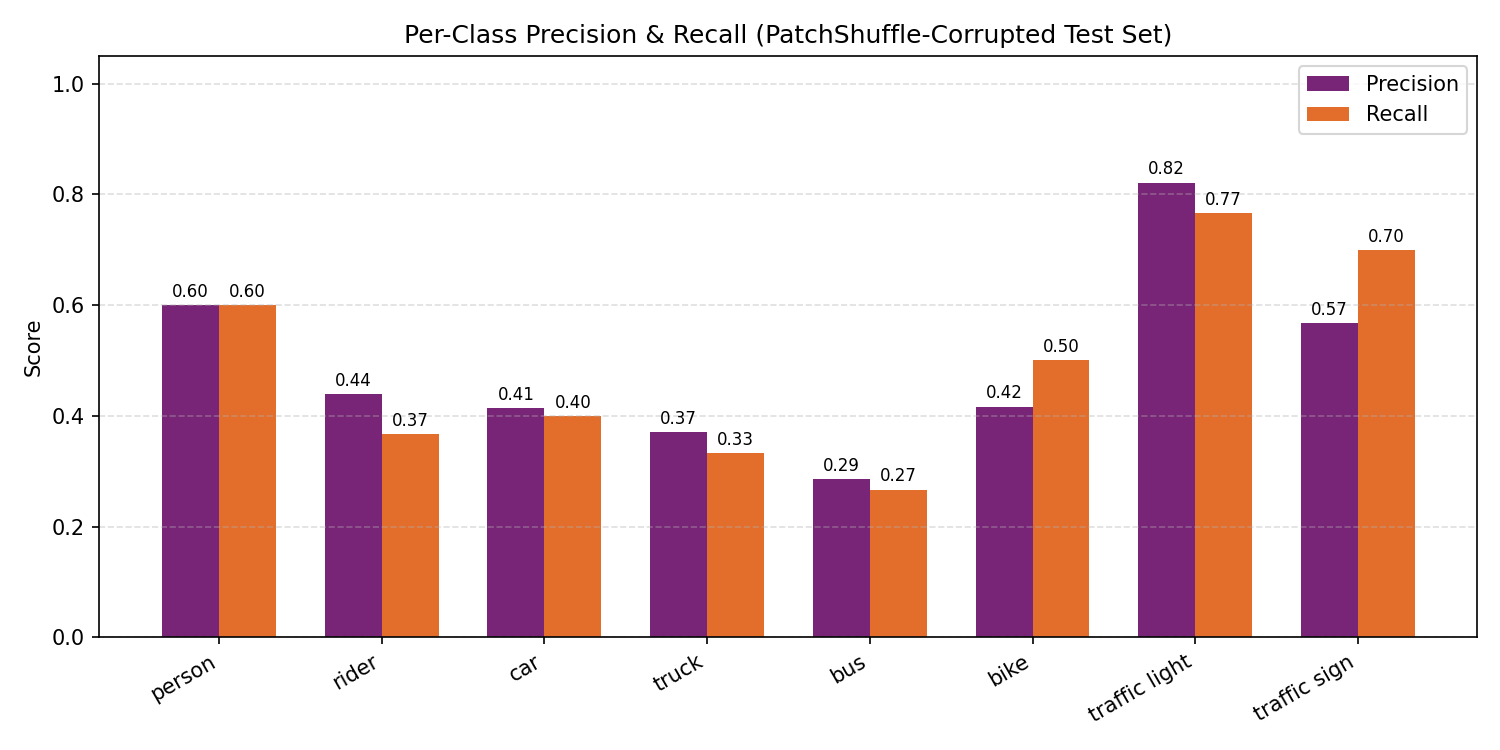

In [44]:
plot_per_class_metrics(
    class_names,
    corrupt_per_class_precision,
    corrupt_per_class_recall,
    save_path="per_class_metrics.png",
    title="Per-Class Precision & Recall (PatchShuffle-Corrupted Test Set)",
)

# Display inline in the notebook
from IPython.display import Image as IPyImage
IPyImage(filename="per_class_metrics.png")


In [45]:
(_clean_per_class_precision,
 _clean_per_class_recall,
 clean_macro_precision,
 clean_macro_recall) = evaluate(model, clean_test_loader, "cpu", num_classes)

print("--- Clean (uncorrupted) test set ---")
print(f"  Aggregated (macro) precision: {clean_macro_precision:.3f}")
print(f"  Aggregated (macro) recall:    {clean_macro_recall:.3f}")

print("\n=== Final 4 aggregated scalars ===")
print(f"corrupted_precision = {corrupt_macro_precision:.4f}")
print(f"corrupted_recall    = {corrupt_macro_recall:.4f}")
print(f"clean_precision     = {clean_macro_precision:.4f}")
print(f"clean_recall        = {clean_macro_recall:.4f}")



--- Clean (uncorrupted) test set ---
  Aggregated (macro) precision: 0.489
  Aggregated (macro) recall:    0.492

=== Final 4 aggregated scalars ===
corrupted_precision = 0.4894
corrupted_recall    = 0.4917
clean_precision     = 0.4894
clean_recall        = 0.4917


# Task 3

In [46]:
# ── Task 3: frozen ViT-B/16 feature extractor (IMAGENET1K_V1) ─────────────────
from torchvision.models import vit_b_16, ViT_B_16_Weights

# 1. Pretrained weights + their matching preprocessing
#    (resize 256 -> center-crop 224 -> ToTensor -> ImageNet normalization)
vit_weights    = ViT_B_16_Weights.IMAGENET1K_V1
vit_preprocess = vit_weights.transforms()

# 2. Build backbone, strip the 1000-class head so forward() returns the
#    768-d CLS-token feature, FREEZE all params, put in eval mode.
feature_extractor = vit_b_16(weights=vit_weights)
feature_extractor.heads = nn.Identity()                 # remove classification head
for param in feature_extractor.parameters():
    param.requires_grad_(False)                          # freeze the backbone
feature_extractor = feature_extractor.to(DEVICE).eval()

n_trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Backbone: ViT-B/16 (IMAGENET1K_V1) | trainable params: {n_trainable}")  # -> 0

Backbone: ViT-B/16 (IMAGENET1K_V1) | trainable params: 0


In [47]:
# ── Uncorrupted (clean) train + test sets, preprocessed for the pretrained ViT ─
# NOTE: img_transform = vit_preprocess only  -> NO PatchShuffle (clean images),
#       and it's deterministic (no random augmentation) so features are stable.
vit_train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=vit_preprocess,
)
vit_test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=vit_preprocess,
)

# shuffle=False so feature rows stay aligned with label order
vit_train_loader = DataLoader(vit_train_dataset, batch_size=32, shuffle=False, num_workers=0)
vit_test_loader  = DataLoader(vit_test_dataset,  batch_size=32, shuffle=False, num_workers=0)

In [48]:
# ── Extract features for ALL train + test images ──────────────────────────────
@torch.no_grad()
def extract_features(model, loader, device):
    """Run the frozen backbone over a loader -> (features [N, 768], labels [N])."""
    feats, lbls = [], []
    for images, labels in loader:
        images = images.to(device)
        f = model(images)                 # [B, 768] CLS-token embeddings
        feats.append(f.cpu())
        lbls.append(labels)
    return torch.cat(feats), torch.cat(lbls)

train_features, train_labels = extract_features(feature_extractor, vit_train_loader, DEVICE)
test_features,  test_labels  = extract_features(feature_extractor, vit_test_loader,  DEVICE)

print(f"train_features: {tuple(train_features.shape)} | train_labels: {tuple(train_labels.shape)}")
print(f"test_features:  {tuple(test_features.shape)}  | test_labels:  {tuple(test_labels.shape)}")

train_features: (2400, 768) | train_labels: (2400,)
test_features:  (240, 768)  | test_labels:  (240,)


In [49]:
# Reference implementation of the optional helper class (frozen ViT-B/16 + linear head).
# NOTE: For efficiency the cells below train the probe on the CACHED features extracted
# above. Because the backbone is frozen, that is mathematically equivalent to training
# this end-to-end module (the frozen backbone would output the exact same features).


class LinearProbeClassifier(nn.Module):
    """Frozen pretrained ViT-B/16 backbone + a single trainable linear head."""

    def __init__(self, backbone_arch: str = "vit_b_16", num_classes: int = 8):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.backbone = vit_b_16(weights=weights)

        # ViT's classification head lives in `.heads`; grab its input dim (768) first,
        # then replace the head with Identity so the backbone returns CLS features.
        self.feat_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()

        # Freeze the backbone: its parameters are not updated during training.
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        self.backbone.eval()

        # The only trainable part: a linear classifier on top of the features.
        self.linear_head = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x: torch.Tensor):
        with torch.no_grad():               # frozen feature extractor
            feats = self.backbone(x)
        return self.linear_head(feats)       # logits

In [50]:
# ── Task 3 (2): Linear probing on the frozen ViT features ──────────────────
# Train ONLY a linear layer (nn.Linear(768 -> n_classes)) on top of the frozen CLS-token
# features extracted above. Backbone stays frozen -> this is a linear probe.
# (optim, nn, DEVICE already imported/defined earlier.)
feat_dim    = train_features.shape[1]               # 768 for ViT-B/16
n_classes   = vit_train_dataset.num_classes         # 8

# cached features -> training device
Xtr, ytr = train_features.to(DEVICE), train_labels.to(DEVICE)
Xte, yte = test_features.to(DEVICE),  test_labels.to(DEVICE)

linear_probe = nn.Linear(feat_dim, n_classes).to(DEVICE)
probe_opt    = optim.Adam(linear_probe.parameters(), lr=1e-3)
probe_crit   = nn.CrossEntropyLoss()

batch_size, n_train = 32, Xtr.size(0)
probe_losses = []
for epoch in range(10):                             # assignment: linear head <= 10 epochs
    linear_probe.train()
    perm       = torch.randperm(n_train, device=DEVICE)   # reshuffle each epoch
    epoch_loss = 0.0
    for i in range(0, n_train, batch_size):         # mini-batches of size 32
        b = perm[i:i + batch_size]
        probe_opt.zero_grad()
        loss = probe_crit(linear_probe(Xtr[b]), ytr[b])
        loss.backward()
        probe_opt.step()
        epoch_loss += loss.item() * b.size(0)
    epoch_loss /= n_train                            # sample-weighted mean loss
    probe_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d}/10 | train CE loss: {epoch_loss:.4f}")

# predictions on the CLEAN (uncorrupted) test set
linear_probe.eval()
with torch.no_grad():
    probe_test_preds = linear_probe(Xte).argmax(dim=1).cpu().numpy()
probe_test_targets = yte.cpu().numpy()

Epoch 01/10 | train CE loss: 1.3883
Epoch 02/10 | train CE loss: 1.0026
Epoch 03/10 | train CE loss: 0.8938
Epoch 04/10 | train CE loss: 0.8271
Epoch 05/10 | train CE loss: 0.7802
Epoch 06/10 | train CE loss: 0.7349
Epoch 07/10 | train CE loss: 0.6955
Epoch 08/10 | train CE loss: 0.6712
Epoch 09/10 | train CE loss: 0.6462
Epoch 10/10 | train CE loss: 0.6189


In [51]:
# ── Task 3 (3): kNN with k selected on a validation split ──────────────────
# One helper for distance-based prediction (shared by selection + final test) and
# one metric helper (shared by probe, kNN and the comparison) -> no duplicated logic.
def knn_predict(train_X, train_y, query_X, k):
    d   = torch.cdist(query_X, train_X)               # [N_query, N_train], Euclidean
    idx = d.topk(k, dim=1, largest=False).indices     # k nearest neighbours
    return torch.mode(train_y[idx], dim=1).values      # majority vote

def macro_prec_recall(preds, targets, n=8):
    # per-class precision & recall (average=None, as in Task 2) ...
    precision, recall, _, _ = precision_recall_fscore_support(
        targets, preds, labels=list(range(n)), average=None, zero_division=0,
    )
    return np.mean(precision), np.mean(recall)        # ... averaged over the 8 classes

# carve a validation set out of the cached TRAIN features (used only to pick k)
perm             = torch.randperm(train_features.size(0))
n_val            = int(0.2 * train_features.size(0))
val_ids, fit_ids = perm[:n_val], perm[n_val:]
fitX, fity       = train_features[fit_ids], train_labels[fit_ids]
valX, valy       = train_features[val_ids], train_labels[val_ids]

best_k, best_score = None, -1.0
for k in [1, 5, 11, 25, 49]:
    p, r  = macro_prec_recall(knn_predict(fitX, fity, valX, k).numpy(), valy.numpy())
    score = 0.5 * (p + r)                             # balance precision & recall
    print(f"k={k:>2} | val macro recall {r:.3f} | val macro precision {p:.3f}")
    if score > best_score:
        best_k, best_score = k, score
print(f"Selected k = {best_k}")

# final prediction on the CLEAN test set with the best k (all train features as neighbours)
knn_test_preds   = knn_predict(train_features, train_labels, test_features, best_k).numpy()
knn_test_targets = test_labels.numpy()

k= 1 | val macro recall 0.470 | val macro precision 0.472
k= 5 | val macro recall 0.533 | val macro precision 0.575
k=11 | val macro recall 0.563 | val macro precision 0.610
k=25 | val macro recall 0.538 | val macro precision 0.607
k=49 | val macro recall 0.537 | val macro precision 0.647
Selected k = 49


In [52]:
# ── Task 3 (4): macro metrics for all three methods (helpers defined above) ──
probe_prec, probe_recall = macro_prec_recall(probe_test_preds, probe_test_targets)
knn_prec,   knn_recall   = macro_prec_recall(knn_test_preds,   knn_test_targets)

# Task 3 uses the UNCORRUPTED dataset -> compare against the Task-2 model on the
# CLEAN test set (clean_macro_precision / clean_macro_recall come from Task 2's run).
task2_prec, task2_recall = clean_macro_precision, clean_macro_recall

print(f"ViT + linear probe   | macro recall {probe_recall:.3f} | macro precision {probe_prec:.3f}")
print(f"ViT + kNN (k={best_k}) | macro recall {knn_recall:.3f} | macro precision {knn_prec:.3f}")
print(f"Task 2 from scratch  | macro recall {task2_recall:.3f} | macro precision {task2_prec:.3f}")

ViT + linear probe   | macro recall 0.583 | macro precision 0.589
ViT + kNN (k=49) | macro recall 0.517 | macro precision 0.555
Task 2 from scratch  | macro recall 0.492 | macro precision 0.489


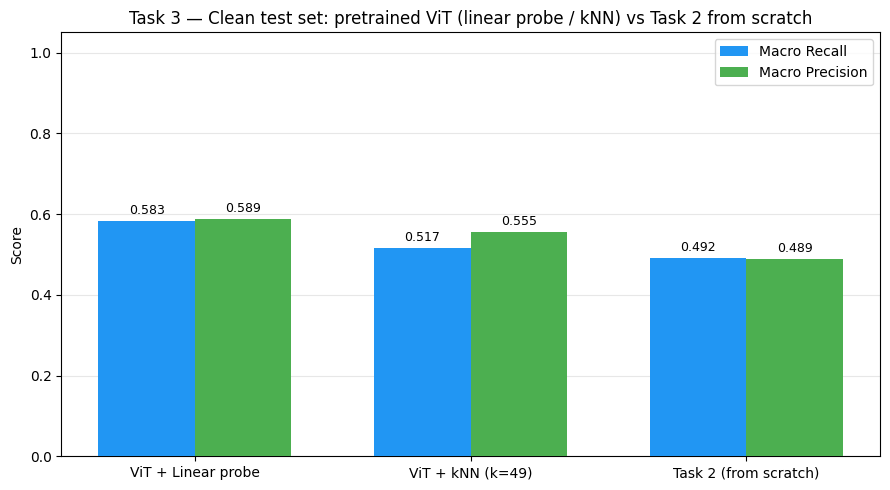

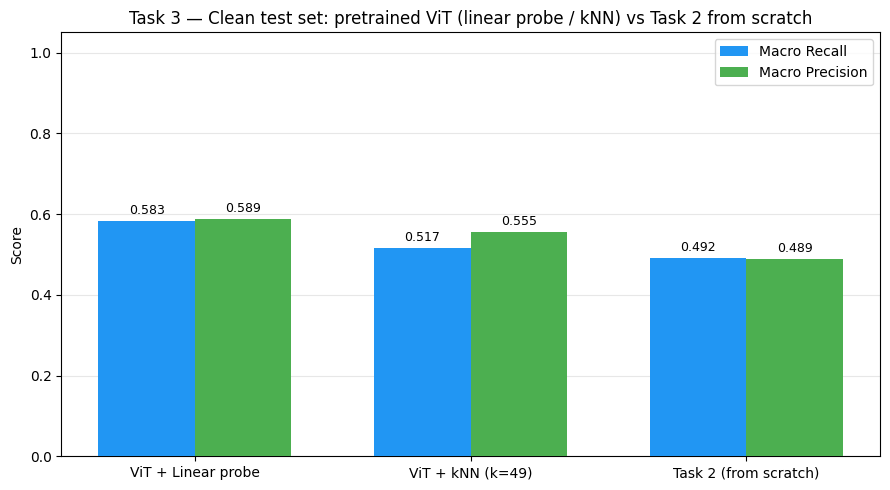

In [55]:
# ── Task 3 (5): comparison figure (plt, np already imported) ───────────────
methods = ["ViT + Linear probe", f"ViT + kNN (k={best_k})", "Task 2 (from scratch)"]
recalls = [probe_recall, knn_recall, task2_recall]
precs   = [probe_prec,   knn_prec,   task2_prec]

x, w = np.arange(len(methods)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w / 2, recalls, w, label="Macro Recall",    color="#2196F3", zorder=3)
b2 = ax.bar(x + w / 2, precs,   w, label="Macro Precision", color="#4CAF50", zorder=3)

for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Task 3 — Clean test set: pretrained ViT (linear probe / kNN) vs Task 2 from scratch")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_task3.png", dpi=150, bbox_inches="tight")
plt.show()